#### 이자율변수만으로_분류모델 실험 251031

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df = df[['loan_int_rate', 'loan_grade']]

In [4]:
df.isnull().sum()

loan_int_rate    3116
loan_grade          0
dtype: int64

In [5]:
# 값이 다 NaN이므로 행 자체를 날려도 될듯 
print(df[df.isnull()]['loan_int_rate'].unique())  
print(df[df.isnull()]['loan_grade'].unique()) 
df[df.isnull()]

[nan]
[nan]


,loan_int_rate,loan_grade
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
32576,NaN,NaN
32577,NaN,NaN
32578,NaN,NaN
32579,NaN,NaN


In [6]:
df.dropna(axis=0)['loan_grade'].value_counts()

loan_grade
A    9774
B    9395
C    5828
D    3314
E     881
F     214
G      59
Name: count, dtype: int64

In [7]:
df = df.dropna(axis=0)

In [8]:
X = df['loan_int_rate']
y = df['loan_grade']

In [9]:
X.isnull().sum()

0

In [10]:
# 트레이닝/테스트 데이터 분할 
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0, stratify=y)

In [11]:
print(X_tn.shape)
print(X_te.shape)

(22098,)
(7367,)


In [12]:
print(y_tn.value_counts())

loan_grade
A    7330
B    7046
C    4371
D    2485
E     661
F     161
G      44
Name: count, dtype: int64


In [13]:
print(y_te.value_counts())

loan_grade
A    2444
B    2349
C    1457
D     829
E     220
F      53
G      15
Name: count, dtype: int64


<Axes: xlabel='loan_int_rate', ylabel='Count'>

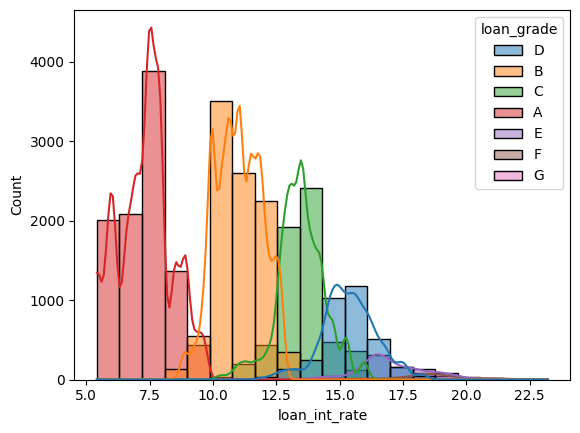

In [14]:
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', bins=20, kde=True, color='cornflowerblue')

['A', 'B', 'C', 'D', 'E', 'F', 'G']


<Axes: xlabel='loan_grade', ylabel='loan_int_rate'>

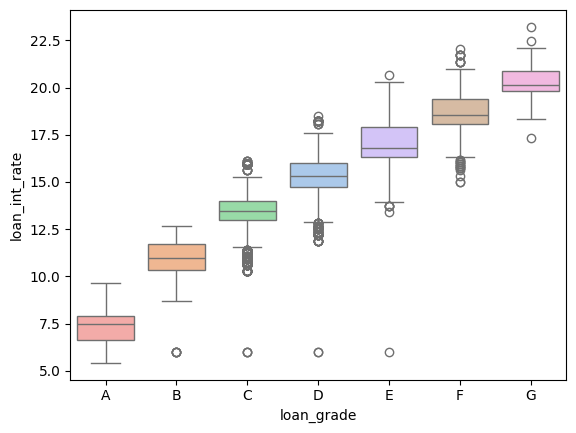

In [15]:
order = sorted(df['loan_grade'].unique())
print(order)
sns.boxplot(data=df, x='loan_grade', y = 'loan_int_rate', hue='loan_grade', palette='pastel', order=order)

#### 로지스틱 모델 돌려보기 

In [16]:
# 로지스틱 회귀분석
from sklearn.linear_model import LogisticRegression
clf_logi = LogisticRegression()
clf_logi.fit(pd.DataFrame(X_tn), y_tn)

LogisticRegression()

In [17]:
# 예측
pred_logistic = clf_logi.predict(pd.DataFrame(X_te))
print(pred_logistic)

['C' 'C' 'D' ... 'A' 'B' 'B']


In [18]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_logistic)
print(conf_matrix)

[[2341  103    0    0    0    0    0]
 [  53 2170  126    0    0    0    0]
 [   1  143 1203  110    0    0    0]
 [   1    8  219  562   39    0    0]
 [   0    0   11  129   80    0    0]
 [   0    0    0    8   45    0    0]
 [   0    0    0    0   15    0    0]]


['A', 'B', 'C', 'D', 'E', 'F', 'G']


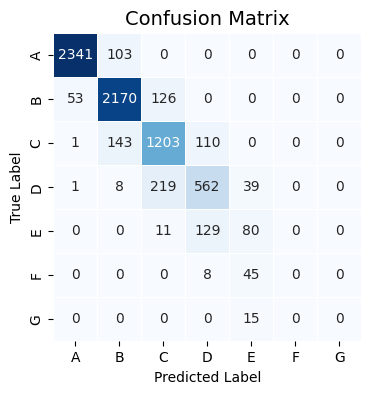

In [21]:
labels = sorted(df['loan_grade'].unique())
print(labels)

plt.figure(figsize=(4,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            linewidths=0.5, cbar=False, square=True)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_logistic)
print(class_report)

              precision    recall  f1-score   support

           A       0.98      0.96      0.97      2444
           B       0.90      0.92      0.91      2349
           C       0.77      0.83      0.80      1457
           D       0.69      0.68      0.69       829
           E       0.45      0.36      0.40       220
           F       0.00      0.00      0.00        53
           G       0.00      0.00      0.00        15

    accuracy                           0.86      7367
   macro avg       0.54      0.54      0.54      7367
weighted avg       0.85      0.86      0.86      7367

